In [18]:
%pip install memory-profiler

import time
import itertools
import matplotlib.pyplot as plt
import networkx as nx
from memory_profiler import memory_usage
import heapq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Distance Matrix (Graph)
dist_matrix = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

# Locations
locations = ['Warehouse', 'A', 'B', 'C']

# Parcel Data: (value, weight, time_window_start, end)
parcels = [
    {'id': 'P1', 'value': 100, 'weight': 5, 'time': (9, 12)},
    {'id': 'P2', 'value': 60, 'weight': 3, 'time': (10, 13)},
    {'id': 'P3', 'value': 120, 'weight': 7, 'time': (11, 15)}
]

# Vehicle Constraint
max_capacity = 10

In [3]:
def route_cost(current, visited):
    if len(visited) == len(dist_matrix):
        return dist_matrix[current][0]  # return to warehouse

    min_cost = float('inf')

    for city in range(len(dist_matrix)):
        if city not in visited:
            cost = dist_matrix[current][city] + route_cost(city, visited + [city])
            min_cost = min(min_cost, cost)

    return min_cost

# Run
print("Minimum Route Cost (Recurrence):", route_cost(0, [0]))

Minimum Route Cost (Recurrence): 80


In [4]:
def greedy_selection(parcels, capacity):
    parcels_sorted = sorted(parcels, key=lambda x: x['value']/x['weight'], reverse=True)

    selected = []
    total_weight = 0

    for p in parcels_sorted:
        if total_weight + p['weight'] <= capacity:
            selected.append(p)
            total_weight += p['weight']

    return selected

selected_parcels = greedy_selection(parcels, max_capacity)
print("Selected Parcels:", selected_parcels)

Selected Parcels: [{'id': 'P1', 'value': 100, 'weight': 5, 'time': (9, 12)}, {'id': 'P2', 'value': 60, 'weight': 3, 'time': (10, 13)}]


In [5]:
def check_time_windows(parcels):
    current_time = 9  # start time

    for p in parcels:
        start, end = p['time']
        if current_time < start:
            current_time = start

        if current_time > end:
            return False

        current_time += 1  # delivery time

    return True

print("Time Window Valid:", check_time_windows(selected_parcels))

Time Window Valid: True


In [16]:
def dijkstra(graph, start):
    n = len(graph)
    dist = [float('inf')] * n
    dist[start] = 0

    pq = [(0, start)]

    while pq:
        current_dist, u = heapq.heappop(pq)

        for v in range(n):
            if graph[u][v] != 0:
                if dist[v] > current_dist + graph[u][v]:
                    dist[v] = current_dist + graph[u][v]
                    heapq.heappush(pq, (dist[v], v))

    return dist

print("Shortest Paths:", dijkstra(dist_matrix, 0))

Shortest Paths: [0, 10, 15, 20]


In [7]:
def prim_mst(graph):
    n = len(graph)
    selected = [False] * n
    selected[0] = True

    edges = []

    for _ in range(n - 1):
        min_edge = (float('inf'), -1, -1)

        for i in range(n):
            if selected[i]:
                for j in range(n):
                    if not selected[j] and graph[i][j]:
                        if graph[i][j] < min_edge[0]:
                            min_edge = (graph[i][j], i, j)

        weight, u, v = min_edge
        selected[v] = True
        edges.append((u, v, weight))

    return edges

print("MST:", prim_mst(dist_matrix))

MST: [(0, 1, 10), (0, 2, 15), (0, 3, 20)]


In [8]:
def tsp_bruteforce(graph):
    n = len(graph)
    nodes = list(range(1, n))

    min_cost = float('inf')
    best_path = None

    for perm in itertools.permutations(nodes):
        cost = 0
        prev = 0

        for node in perm:
            cost += graph[prev][node]
            prev = node

        cost += graph[prev][0]

        if cost < min_cost:
            min_cost = cost
            best_path = perm

    return best_path, min_cost

path, cost = tsp_bruteforce(dist_matrix)
print("TSP Path:", path)
print("TSP Cost:", cost)

TSP Path: (1, 3, 2)
TSP Cost: 80


In [17]:
start = time.time()
route_cost(0, [0])
end = time.time()

print("Execution Time:", end - start)

mem = memory_usage((route_cost, (0, [0])))
print("Memory Usage:", max(mem), "MB")

Execution Time: 0.00011134147644042969
Memory Usage: 147.28125 MB


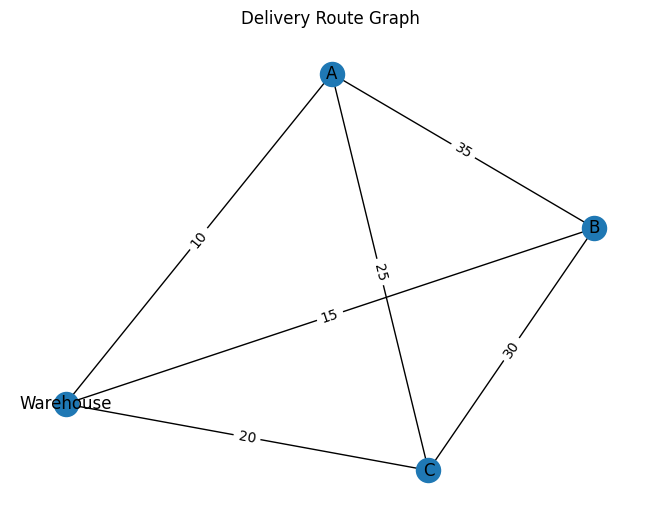

In [10]:
G = nx.Graph()

for i in range(len(dist_matrix)):
    for j in range(i+1, len(dist_matrix)):
        G.add_edge(locations[i], locations[j], weight=dist_matrix[i][j])

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Delivery Route Graph")
plt.show()

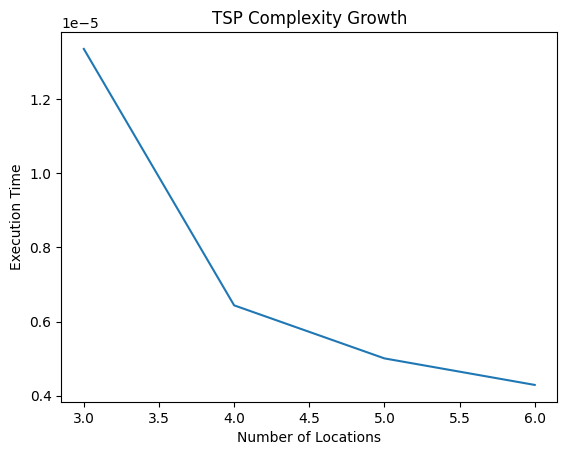

In [11]:
sizes = [3, 4, 5, 6]
times = []

for size in sizes:
    sub_graph = [row[:size] for row in dist_matrix[:size]]

    start = time.time()
    tsp_bruteforce(sub_graph)
    times.append(time.time() - start)

plt.plot(sizes, times)
plt.xlabel("Number of Locations")
plt.ylabel("Execution Time")
plt.title("TSP Complexity Growth")
plt.show()